## Importando as Bibliotecas

In [1]:
# Manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos estatísticos
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Validação e tuning
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve
)

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor

import optuna
import optuna.visualization as viz

import shap

print("Bibliotecas importadas com sucesso!")

c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas importadas com sucesso!


# 1. Leitura e Validação dos Dados

A base tratada é carregada e preparada para a etapa de modelagem, com conversão da variável `data_hora` para o formato temporal e definição do índice cronológico.

Em seguida, são realizadas verificações rápidas para confirmar a estrutura da base, a ausência de valores ausentes, a ordenação temporal, a frequência regular de 10 minutos e o período disponível para análise.

Como o projeto tem foco na previsão do consumo da Zona 1, as variáveis referentes às Zonas 2 e 3 são removidas antes da construção dos modelos.

In [2]:
# Leitura, transformação em datetime e modificando o index
dados = pd.read_csv("../data/dados_tratados.csv")
dados["data_hora"] = pd.to_datetime(dados["data_hora"], format="%Y-%m-%d %H:%M:%S")
dados = dados.set_index("data_hora")
dados = dados.drop(columns=["consumo_zona_2", "consumo_zona_3"])
dados.head()

,temperatura,umidade,velocidade_vento,fluxo_difuso_geral,fluxo_difuso,consumo_zona_1
data_hora,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620


In [3]:
print(f"Classe do Index -> {type(dados.index)}")
print(f"Shape -> {dados.shape}")

print(f"\nValores Ausentes -> {dados.isna().sum().sum()}")

print(f"\nOrdenado -> {dados.index.is_monotonic_increasing}")
print(f"\nFrequência -> {pd.infer_freq(dados.index)}")

print(f"\nPeríodo -> {dados.index.min().date()} até {dados.index.max().date()}")

Classe do Index -> <class 'pandas.DatetimeIndex'>
Shape -> (52416, 6)

Valores Ausentes -> 0

Ordenado -> True

Frequência -> 10min

Período -> 2017-01-01 até 2017-12-30


# 2. Divisão dos Dados de Modelagem e Teste Final

Para preservar a ordem temporal da série e evitar vazamento de informações, os dados são divididos cronologicamente.

O período de janeiro a novembro é utilizado para modelagem, enquanto os últimos 30 dias da série são reservados como conjunto de teste final.

Essa separação permite avaliar o desempenho dos modelos em dados futuros, simulando de forma mais realista um cenário de previsão fora da amostra.

In [4]:
um_mes = 4320

dados_modelagem = dados.iloc[:-um_mes].copy()
teste_final = dados.iloc[-um_mes:].copy()

Dados Modelagem -> 2017-01-01 até 2017-11-30
Teste Final -> 2017-12-01 até 2017-12-30


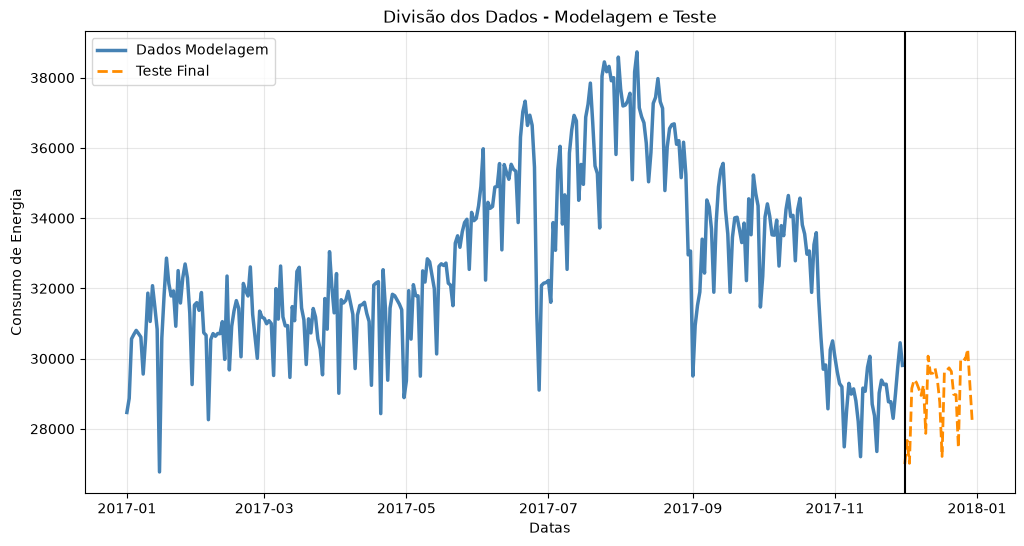

In [5]:
print(f"Dados Modelagem -> {dados_modelagem.index.min().date()} até {dados_modelagem.index.max().date()}")
print(f"Teste Final -> {teste_final.index.min().date()} até {teste_final.index.max().date()}")

modelagem_diaria = dados_modelagem["consumo_zona_1"].resample("D").mean()
teste_diaria = teste_final["consumo_zona_1"].resample("D").mean()

plt.figure(figsize=(12,6))

plt.plot(modelagem_diaria.index, modelagem_diaria, color="steelblue", linewidth=2.5, label="Dados Modelagem")
plt.plot(teste_diaria.index, teste_diaria, color="darkorange", linewidth=2.0 ,linestyle='--', label="Teste Final")
plt.axvline(teste_diaria.index[0], color='black', linewidth=1.5)
plt.title("Divisão dos Dados - Modelagem e Teste")
plt.xlabel("Datas")
plt.ylabel("Consumo de Energia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observação

A divisão mantém a sequência temporal dos dados, sem embaralhamento entre passado e futuro.

O mês final permanece totalmente isolado da etapa de modelagem e será utilizado apenas na avaliação definitiva dos modelos selecionados.

# 3. Definição das Métricas de Avaliação

Para comparar o desempenho dos modelos de forma consistente, são utilizadas as métricas **MAE**, **RMSE** e **MAPE**.

- **MAE:** representa o erro absoluto médio das previsões.
- **RMSE:** penaliza erros maiores com mais intensidade.
- **MAPE:** expressa o erro médio em termos percentuais.

Essas métricas serão utilizadas de forma padronizada ao longo de toda a etapa de modelagem.

In [6]:
def calcula_metricas(y_real, previsto):
    mae = mean_absolute_error(y_real, previsto)
    rmse = np.sqrt(mean_squared_error(y_real, previsto))
    mape = mean_absolute_percentage_error(y_real, previsto)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

# 4. Modelos Estatísticos

A primeira etapa da modelagem utiliza métodos estatísticos de séries temporais como referência para comparação com os modelos de Machine Learning.

Esses modelos permitem avaliar o desempenho de abordagens tradicionais baseadas diretamente na estrutura temporal da série.

## 4.1 Holt-Winters

O Holt-Winters é utilizado como modelo estatístico de referência, considerando tendência e sazonalidade aditivas.

Como a série possui frequência de 10 minutos, é utilizado um período sazonal de **144 observações**, correspondente a um ciclo diário completo.

A avaliação é realizada com `TimeSeriesSplit`, utilizando 5 divisões temporais e janelas de validação equivalentes a 30 dias, preservando a ordem cronológica dos dados.

In [7]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_hw = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(dados_modelagem), start=1):

    treino = dados_modelagem.iloc[train_idx]["consumo_zona_1"]
    validacao = dados_modelagem.iloc[val_idx]["consumo_zona_1"]

    modelo = ExponentialSmoothing(
        treino,
        trend='add',
        seasonal='add',
        seasonal_periods=144
    ).fit()

    previsoes = modelo.forecast(steps=len(validacao))

    metricas = calcula_metricas(validacao, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Holt-Winters"

    resultados_hw.append(metricas)

c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferre

# 5. Modelos de Machine Learning

Nesta etapa, o problema de previsão é transformado em uma tarefa de aprendizado supervisionado.

Além das variáveis meteorológicas, são incorporadas informações temporais derivadas do próprio histórico de consumo, permitindo que os modelos aprendam padrões de curto e longo prazo da série.

## 5.1 Preparação dos Dados para Machine Learning

São criadas features temporais para representar a dinâmica histórica do consumo:

- **Lags:** valores observados há 10 minutos, 1 hora, 1 dia e 1 semana;
- **Médias móveis:** comportamento médio das últimas 1 hora e 24 horas;
- **Variáveis de calendário:** dia da semana e representação cíclica da hora do dia.

As médias móveis são calculadas utilizando apenas informações anteriores ao instante previsto, reduzindo o risco de vazamento de informação.

Como a criação dessas features gera valores ausentes no início da série, essas observações são removidas antes da modelagem.

In [8]:
dados_ml = dados.copy()
target = "consumo_zona_1"

# Lags
dados_ml["lag_1"] = dados_ml[target].shift(1) # 10 min
dados_ml["lag_6"] = dados_ml[target].shift(6) # 1 hora
dados_ml["lag_144"] = dados_ml[target].shift(144) # 1 dia
dados_ml["lag_1008"] = dados_ml[target].shift(1008) # 1 semana

# Médias Móveis
dados_ml["rolling_mean_6"] = dados_ml[target].shift(1).rolling(6).mean()
dados_ml["rolling_mean_144"] = dados_ml[target].shift(1).rolling(144).mean()

# Variáveis Temporais
dados_ml["hora"] = dados_ml.index.hour
dados_ml["dia_da_semana"] = dados_ml.index.dayofweek

# Representação cíclica da hora
dados_ml["hora_sin"] = np.sin(2 * np.pi * dados_ml["hora"] / 24)

dados_ml["hora_cos"] = np.cos(2 * np.pi * dados_ml["hora"] / 24)

# Removendo columa de hora
dados_ml.drop(columns=["hora"], inplace=True)

# Removendo valores nulos
dados_ml = dados_ml.dropna()

In [9]:
dados_ml.head()

,temperatura,umidade,velocidade_vento,fluxo_difuso_geral,fluxo_difuso,consumo_zona_1,lag_1,lag_6,lag_144,lag_1008,rolling_mean_6,rolling_mean_144,dia_da_semana,hora_sin,hora_cos
data_hora,,,,,,,,,,,,,,,
2017-01-08 00:00:00,14.07,78.2,0.081,0.048,0.130,28332.15190,29401.51899,33812.65823,28927.59494,34055.69620,31526.075950,30612.700422,6,0.0,1.0
2017-01-08 00:10:00,14.19,77.8,0.085,0.044,0.111,27791.39241,28332.15190,32955.94937,28052.65823,29814.68354,30612.658228,30608.565401,6,0.0,1.0
2017-01-08 00:20:00,14.27,77.7,0.087,0.033,0.122,26831.39241,27791.39241,31868.35443,27220.25316,29128.10127,29751.898735,30606.751055,6,0.0,1.0
2017-01-08 00:30:00,14.34,77.7,0.092,0.055,0.134,26296.70886,26831.39241,30914.43038,26831.39241,28228.86076,28912.405065,30604.050633,6,0.0,1.0
2017-01-08 00:40:00,14.37,77.9,0.089,0.040,0.137,25585.82278,26296.70886,30203.54430,26363.54430,27335.69620,28142.784812,30600.337552,6,0.0,1.0


## 5.2 Preparação dos Dados de Modelagem e Teste Final

Após a criação das features, a divisão temporal definida anteriormente é reaplicada ao conjunto preparado para Machine Learning.

Os dados anteriores a dezembro são utilizados na etapa de modelagem e validação, enquanto o período final permanece reservado exclusivamente para a avaliação definitiva.

Por fim, são separadas as variáveis explicativas (`X`) e a variável-alvo (`y`) que serão utilizadas pelos modelos.

In [10]:
data_inicio_teste = teste_final.index.min()
print(data_inicio_teste)

2017-12-01 00:00:00


In [11]:
dados_ml_modelagem = dados_ml.iloc[dados_ml.index < data_inicio_teste].copy()
teste_ml_final = dados_ml.iloc[dados_ml.index > data_inicio_teste].copy()

print(f"Dados ML Modelagem -> {dados_ml_modelagem.index.min().date()} até {dados_ml_modelagem.index.max().date()}")
print(f"Teste ML Final -> {teste_ml_final.index.min().date()} até {teste_ml_final.index.max().date()}")

Dados ML Modelagem -> 2017-01-08 até 2017-11-30
Teste ML Final -> 2017-12-01 até 2017-12-30


In [12]:
FEATURES = ['temperatura', 'umidade', 'velocidade_vento', 'fluxo_difuso_geral',
            'fluxo_difuso', 'lag_1', 'lag_6', 'lag_144', 'lag_1008', 'rolling_mean_6',
            'rolling_mean_144', 'dia_da_semana', 'hora_sin', 'hora_cos']

X_modelagem = dados_ml_modelagem[FEATURES]
y_modelagem = dados_ml_modelagem["consumo_zona_1"]

X_teste_final = teste_ml_final[FEATURES]
y_teste_final = teste_ml_final["consumo_zona_1"]

## 5.3 Modelo Random Forest

O Random Forest é utilizado como primeiro modelo de Machine Learning, combinando múltiplas árvores de decisão para capturar relações não lineares entre as variáveis explicativas e o consumo energético.

A avaliação é realizada com `TimeSeriesSplit`, utilizando 5 divisões temporais e janelas de validação de 30 dias, mantendo a ordem cronológica da série.

In [13]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_rf = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Random Forest"

    resultados_rf.append(metricas)

## 5.4 Modelo XGBoost

O XGBoost é avaliado como uma abordagem baseada em Gradient Boosting, capaz de modelar relações complexas e não lineares entre as features temporais, meteorológicas e o consumo energético.

Nesta etapa, o modelo é treinado com uma configuração inicial de hiperparâmetros e avaliado utilizando a mesma estratégia de validação temporal aplicada aos demais modelos.

In [14]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_xgb = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo_xgb = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=5,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost"

    resultados_xgb.append(metricas)

## 5.5 Modelo LightGBM

O LightGBM é incluído na comparação por sua eficiência no treinamento de modelos baseados em Gradient Boosting e sua capacidade de lidar com relações não lineares.

Assim como os demais modelos, sua avaliação utiliza 5 divisões temporais com janelas de validação de 30 dias, garantindo uma comparação consistente entre as abordagens.

In [15]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_gbm = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "LightGBM"

    resultados_gbm.append(metricas) 

# 6. Comparação Inicial dos Modelos

Os resultados obtidos em cada fold são consolidados para comparar o desempenho médio e a variabilidade dos modelos.

São analisadas as médias e os desvios padrão de MAE, RMSE e MAPE, permitindo avaliar não apenas a precisão média, mas também a estabilidade dos modelos ao longo das diferentes janelas temporais.

In [16]:
df_hw = pd.DataFrame(resultados_hw)
df_rf = pd.DataFrame(resultados_rf)
df_xgb = pd.DataFrame(resultados_xgb)
df_gbm = pd.DataFrame(resultados_gbm)

resultados = pd.concat([df_hw, df_rf, df_xgb, df_gbm])

comparacao = resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3)
comparacao = comparacao.sort_values(by=("MAE", "mean"), ascending=True)
comparacao

MAE                    RMSE                MAPE        
                     mean         std        mean         std    mean     std
Modelo                                                                       
LightGBM          317.738      89.830     474.251     134.642   0.010   0.002
Random Forest     495.382      97.251     710.278     148.177   0.015   0.002
XGBoost           495.382      97.251     710.278     148.177   0.015   0.002
Holt-Winters   344768.376  327795.861  397935.269  378324.717  11.440  11.179

### Observação

Na comparação inicial, o **LightGBM apresentou o melhor desempenho entre os modelos de Machine Learning**, com menores valores médios de MAE, RMSE e MAPE.

Random Forest e XGBoost apresentaram resultados inferiores nesta configuração inicial, indicando espaço para otimização de hiperparâmetros.

O Holt-Winters apresentou erros significativamente superiores aos modelos de Machine Learning, sugerindo dificuldade em representar adequadamente a dinâmica da série neste horizonte de validação.

Os resultados idênticos observados entre Random Forest e XGBoost também devem ser revisados para confirmar se não houve reutilização ou associação incorreta dos resultados durante a consolidação das métricas.

# 7. Otimização de Hiperparâmetros — RandomizedSearchCV

Após a comparação inicial, os modelos XGBoost e LightGBM são submetidos à otimização de hiperparâmetros com `RandomizedSearchCV`.

A busca utiliza a mesma estratégia de validação temporal (`TimeSeriesSplit`) adotada anteriormente, mantendo a ordem cronológica da série.

O critério de seleção é o **MAE**, buscando configurações capazes de reduzir o erro médio das previsões sem comprometer a capacidade de generalização.# 7. Otimiazação de Hiperparãmetros - RandomSearchCV

## 7.1 Otimização do XGBoost

O espaço de busca inclui parâmetros relacionados à quantidade e profundidade das árvores, taxa de aprendizado, amostragem e regularização.

O `RandomizedSearchCV` avalia diferentes combinações desses hiperparâmetros e seleciona aquela que apresenta o melhor desempenho médio durante a validação temporal.

In [17]:
modelo_xgb = xgb.XGBRegressor(ojective="reg:absoluteerror", random_state=42, n_jobs=-1)

parametros_xgb = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [ 0.9, 1.0],
    "colsample_bytree": [ 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

busca_xgb = RandomizedSearchCV(
    estimator=modelo_xgb,
    param_distributions=parametros_xgb,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

busca_xgb.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparametros -> {busca_xgb.best_params_}")
print(f"Melhor Resultado MAE -> {-busca_xgb.best_score_}")

c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:04:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "ojective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhores Hiperparametros -> {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Melhor Resultado MAE -> 294.95312335325525


## 7.2 Otimização do LightGBM

O LightGBM também é otimizado por meio de busca aleatória, explorando parâmetros relacionados à complexidade das árvores, taxa de aprendizado, número de folhas, amostragem e regularização.

A melhor configuração é selecionada com base no menor MAE médio obtido ao longo das divisões temporais.

In [18]:
modelo_gbm = LGBMRegressor(objective="regression", random_state=42, n_jobs=1, verbosity=-1)

parametros_lgbm = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [5, 7, 10],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0, 1, 5, 10]
}

busca_gbm = RandomizedSearchCV(
    estimator=modelo_gbm,
    param_distributions=parametros_lgbm,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

busca_gbm.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparâmetros -> {busca_gbm.best_params_}")
print(f"Melhor Resultado MAE -> {-busca_gbm.best_score_}")

Melhores Hiperparâmetros -> {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Melhor Resultado MAE -> 296.2666129431808


# 8. Avaliação dos Modelos Otimizados

Após a etapa de otimização, XGBoost e LightGBM são avaliados novamente utilizando os melhores hiperparâmetros encontrados.

A mesma estratégia com `TimeSeriesSplit` é mantida, garantindo uma comparação justa com os modelos anteriores e permitindo verificar se o tuning trouxe ganhos consistentes de desempenho.# 8. Avaliação dos Modelos Otimizados

In [19]:
resultados_xgb_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = xgb.XGBRegressor(**busca_xgb.best_params_, objective="reg:squarederror", random_state=42, n_jobs=-1)

    modelo.fit(X_treino, y_treino)
    previsoes = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost Tunnado"

    resultados_xgb_tuned.append(metricas)

In [20]:
resultados_gbm_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = LGBMRegressor(**busca_gbm.best_params_, objective="regression", random_state=42, n_jobs=1, verbosity=-1)

    modelo.fit(X_treino, y_treino)
    previsoes = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "LightGBM Tunnado"

    resultados_gbm_tuned.append(metricas)

## 8.1 Comparação Final dos Modelos

Os resultados dos modelos otimizados são consolidados juntamente com os modelos avaliados anteriormente.

A comparação considera a média e o desvio padrão de MAE, RMSE e MAPE ao longo dos folds, permitindo avaliar simultaneamente desempenho e estabilidade.

In [21]:
df_xgb_tunado = pd.DataFrame(resultados_xgb_tuned)
df_gbm_tunado = pd.DataFrame(resultados_gbm_tuned)

resultados = pd.concat([resultados, df_xgb_tunado, df_gbm_tunado])

comparacao = resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3)
comparacao = comparacao.sort_values(by=("MAE", "mean"), ascending=True)

In [22]:
comparacao = comparacao.drop(index="Holt-Winters")
comparacao

MAE             RMSE            MAPE       
                     mean     std     mean      std   mean    std
Modelo                                                           
XGBoost Tunnado   294.549  82.770  454.535  133.843  0.009  0.002
LightGBM Tunnado  296.267  84.126  450.788  130.321  0.009  0.002
LightGBM          317.738  89.830  474.251  134.642  0.010  0.002
Random Forest     495.382  97.251  710.278  148.177  0.015  0.002
XGBoost           495.382  97.251  710.278  148.177  0.015  0.002

### Observação

A otimização melhorou de forma significativa o desempenho de XGBoost e LightGBM em relação às versões iniciais.

O **XGBoost otimizado apresentou o menor MAE médio**, enquanto o **LightGBM otimizado apresentou o menor RMSE médio**. Ambos alcançaram MAPE próximo de **0,9%**, indicando desempenho bastante semelhante.

Como os resultados são muito próximos, a escolha do modelo final deve considerar também estabilidade entre os folds, comportamento no teste final e facilidade de interpretação.

# 9. Otimização do XGBoost com Optuna

Após a otimização inicial com `RandomizedSearchCV`, o XGBoost é submetido a uma segunda estratégia de busca utilizando o Optuna.

O objetivo é explorar o espaço de hiperparâmetros de forma mais flexível, utilizando o algoritmo TPE para direcionar progressivamente a busca para regiões mais promissoras.

A função objetivo utiliza `TimeSeriesSplit` com 5 divisões e MAE como métrica de otimização, preservando a estrutura temporal da série.

## 9.1 Execução da Otimização

O estudo é configurado para minimizar o MAE médio obtido durante a validação temporal.

São avaliados hiperparâmetros relacionados à complexidade das árvores, taxa de aprendizado, amostragem e regularização, totalizando 20 tentativas de otimização.

In [23]:
tscv = TimeSeriesSplit(n_splits=5, test_size=4320)

def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 1000, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "subsample": trial.suggest_float("subsample", 0.85, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.85, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0)
    }

    modelo = xgb.XGBRegressor(**params, objective="reg:squarederror", tree_method="hist", random_state=42, n_jobs=1)

    score = cross_val_score(modelo, X_modelagem, y_modelagem, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1).mean()

    return -score

In [24]:
sampler = optuna.samplers.TPESampler(seed=42)

study_xgb = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study_xgb.optimize(
    objective_xgb,
    n_trials=20
)

[I 2026-09-19 09:06:34,832] A new study created in memory with name: no-name-b9ae018a-d7f8-4fe3-9b9e-2d6c84e7726b
[I 2026-09-19 09:06:53,622] Trial 0 finished with value: 315.50940898725406 and parameters: {'n_estimators': 600, 'learning_rate': 0.07220721098226064, 'max_depth': 9, 'min_child_weight': 5, 'subsample': 0.8734027960663655, 'colsample_bytree': 0.8733991780504303, 'reg_alpha': 0.00017775399007348227, 'reg_lambda': 9.515184190867908, 'gamma': 1.2022300234864176}. Best is trial 0 with value: 315.50940898725406.
[I 2026-09-19 09:07:33,369] Trial 1 finished with value: 305.9091615870515 and parameters: {'n_estimators': 850, 'learning_rate': 0.010437335666720523, 'max_depth': 10, 'min_child_weight': 7, 'subsample': 0.8818508666017414, 'colsample_bytree': 0.877273745081065, 'reg_alpha': 0.000614933705708711, 'reg_lambda': 1.4072546358030324, 'gamma': 1.0495128632644757}. Best is trial 1 with value: 305.9091615870515.
[I 2026-09-19 09:07:49,779] Trial 2 finished with value: 304.200

In [25]:
print(f"Melhor MAE -> {study_xgb.best_value:.4f}")

print(f"Melhores Hiperparâmetros -> {study_xgb.best_params}")

Melhor MAE -> 296.5647
Melhores Hiperparâmetros -> {'n_estimators': 800, 'learning_rate': 0.01803615730939571, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.8682133194282042, 'colsample_bytree': 0.9991105289762969, 'reg_alpha': 0.04982647798658546, 'reg_lambda': 11.535091545257742, 'gamma': 0.8338003133269434}


## 9.2 Análise do Processo de Otimização

O histórico de otimização permite acompanhar a evolução do melhor MAE ao longo das tentativas realizadas.

Também é analisada a importância relativa dos hiperparâmetros, indicando quais configurações exerceram maior influência sobre o desempenho encontrado durante a busca.

In [26]:
fig1 = viz.plot_optimization_history(study_xgb, target_name="MAE")
fig1.show()

fig2 = viz.plot_param_importances(study_xgb, target_name="MAE")
fig2.show()

### Observação

O histórico mostra uma redução gradual do melhor MAE ao longo das tentativas, indicando que o Optuna conseguiu encontrar configurações mais promissoras durante a busca.

Os parâmetros de regularização, especialmente `reg_alpha` e `reg_lambda`, apresentaram maior influência no resultado do estudo, seguidos por `min_child_weight`.

Como foram executadas apenas **20 tentativas**, a importância dos hiperparâmetros deve ser interpretada como indicativa, e não como uma conclusão definitiva sobre o comportamento do modelo.

## 9.3 Avaliação do XGBoost Otimizado com Optuna

O XGBoost é treinado novamente utilizando os melhores hiperparâmetros encontrados pelo Optuna.

A avaliação utiliza a mesma estratégia de `TimeSeriesSplit`, permitindo comparar o novo modelo diretamente com as versões anteriores.

In [27]:
tscv = TimeSeriesSplit(n_splits=5, test_size=4320)

resultado_xgb_optuna = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost Optuna"

    resultado_xgb_optuna.append(metricas)

In [28]:
df_xgb_optuna = pd.DataFrame(resultado_xgb_optuna)
resultados = pd.concat([resultados, df_xgb_optuna])

comparacao = resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"])
comparacao = comparacao.sort_values(by=("MAE", "mean"), ascending=True)
comparacao

MAE                          RMSE                 \
                           mean            std           mean            std   
Modelo                                                                         
XGBoost Tunnado      294.549268      82.769657     454.534571     133.842724   
LightGBM Tunnado     296.266613      84.126082     450.787825     130.321492   
XGBoost Optuna       298.196003      88.253454     455.250500     139.633280   
LightGBM             317.737596      89.830464     474.251256     134.642482   
XGBoost              495.382395      97.250696     710.277637     148.177383   
Random Forest        495.382395      97.250696     710.277637     148.177383   
Holt-Winters      344768.375719  327795.861313  397935.269063  378324.716666   

                       MAPE             
                       mean        std  
Modelo                                  
XGBoost Tunnado    0.008950   0.001953  
LightGBM Tunnado   0.009005   0.001924  
XGBoost Optuna     0.009016   0.001974  
LightGBM           0.009693   0.002222  
XGBoost            0.014686   0.001896  
Random Forest      0.014686   0.001896  
Holt-Winters      11.440383  11.179184

### Observação

O XGBoost otimizado com Optuna apresentou desempenho competitivo, porém não superou a configuração encontrada anteriormente pelo `RandomizedSearchCV`.

O XGBoost otimizado pela busca aleatória manteve o menor MAE médio, enquanto o LightGBM otimizado apresentou o menor RMSE médio.

Esse resultado mostra que uma estratégia de otimização mais sofisticada não garante necessariamente melhor desempenho, especialmente quando o número de tentativas é limitado. A comparação empírica entre as abordagens continua sendo essencial para a seleção do modelo.

# 10. Ensemble com Voting Regressor

Após a otimização individual dos modelos, é avaliada uma estratégia de ensemble utilizando o `VotingRegressor`.

O ensemble combina as previsões das versões otimizadas de **XGBoost** e **LightGBM**, utilizando a média das previsões individuais como resultado final.

A avaliação mantém o `TimeSeriesSplit` com 5 divisões e janelas de 30 dias, garantindo consistência com os experimentos anteriores.

In [29]:
modelo_xgb_tunado = busca_xgb.best_estimator_
modelo_gbm_tunado = busca_gbm.best_estimator_

In [30]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultado_voting = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = VotingRegressor(
        estimators=[
            ("xgboost", modelo_xgb_tunado),
            ("lightgbm", modelo_gbm_tunado)
        ],
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Modelo Voting Regressor"

    resultado_voting.append(metricas)

### Observação

O objetivo do Voting Regressor é aproveitar características complementares dos dois modelos, reduzindo erros individuais por meio da combinação de suas previsões.

Como não foram definidos pesos específicos, XGBoost e LightGBM possuem a mesma contribuição na previsão final.

# 11. Ensemble com Stacking Regressor

Como segunda estratégia de ensemble, é utilizado o `StackingRegressor`, combinando XGBoost e LightGBM como modelos base.

As previsões produzidas por esses modelos são utilizadas por uma regressão linear como estimador final, permitindo que o ensemble aprenda uma combinação entre as diferentes previsões.

In [31]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultado_stacking = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = StackingRegressor(
        estimators=[
            ("xgboost", modelo_xgb_tunado),
            ("lightbgm", modelo_gbm_tunado)
        ],
        final_estimator=LinearRegression(),
        cv=5,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Modelo Stacking Regressor"

    resultado_stacking.append(metricas)

### Observação

Diferentemente do Voting, que utiliza uma média direta, o Stacking busca aprender como combinar as previsões dos modelos base.

Essa abordagem pode explorar complementaridades entre XGBoost e LightGBM, atribuindo implicitamente diferentes contribuições a cada modelo na previsão final.

# 12. Comparação dos Modelos

Os resultados das estratégias individuais e dos ensembles são consolidados para uma comparação final.

A análise considera as médias e os desvios padrão de **MAE, RMSE e MAPE** obtidos durante a validação temporal, permitindo comparar precisão e estabilidade entre as diferentes abordagens.

In [32]:
df_voting = pd.DataFrame(resultado_voting)
df_stacking = pd.DataFrame(resultado_stacking)
resultados = pd.concat([resultados, df_voting, df_stacking])

In [33]:
comparacao = resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"])
comparacao = comparacao.sort_values(by=("MAE","mean"), ascending=True)

In [34]:
comparacao = comparacao.drop(index="Holt-Winters")
comparacao

MAE                   RMSE              \
                                 mean        std        mean         std   
Modelo                                                                     
Modelo Voting Regressor    290.912000  83.191688  448.581183  132.477045   
XGBoost Tunnado            294.549268  82.769657  454.534571  133.842724   
LightGBM Tunnado           296.266613  84.126082  450.787825  130.321492   
Modelo Stacking Regressor  297.637938  83.663964  452.141490  128.540841   
XGBoost Optuna             298.196003  88.253454  455.250500  139.633280   
LightGBM                   317.737596  89.830464  474.251256  134.642482   
XGBoost                    495.382395  97.250696  710.277637  148.177383   
Random Forest              495.382395  97.250696  710.277637  148.177383   

                               MAPE            
                               mean       std  
Modelo                                         
Modelo Voting Regressor    0.008835  0.001924  
XGBoost Tunnado            0.008950  0.001953  
LightGBM Tunnado           0.009005  0.001924  
Modelo Stacking Regressor  0.009039  0.001918  
XGBoost Optuna             0.009016  0.001974  
LightGBM                   0.009693  0.002222  
XGBoost                    0.014686  0.001896  
Random Forest              0.014686  0.001896

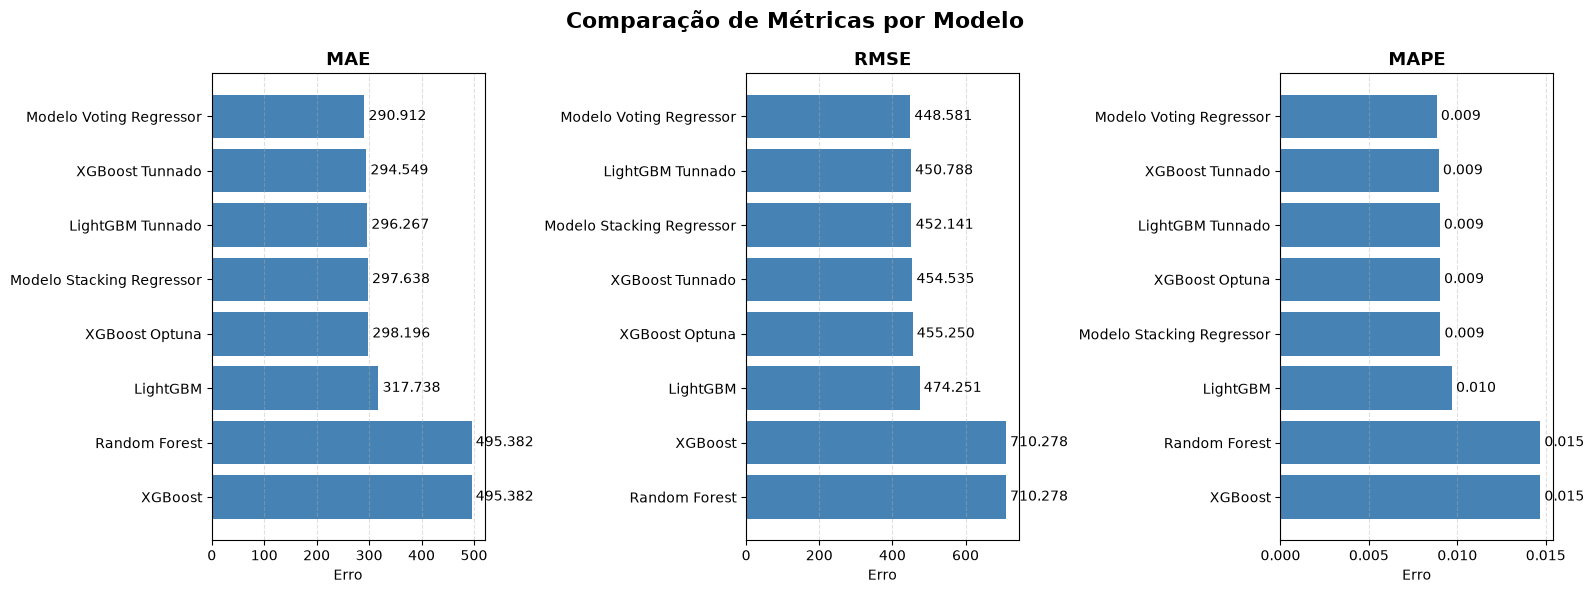

In [35]:
metricas_plot = pd.DataFrame({
    "MAE": comparacao[("MAE", "mean")],
    "RMSE": comparacao[("RMSE", "mean")],
    "MAPE": comparacao[("MAPE", "mean")]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metricas = ["MAE", "RMSE", "MAPE"]

for ax, metrica in zip(axes, metricas):

    valores = metricas_plot[metrica].sort_values(ascending=False)

    bars = ax.barh(valores.index, valores.values, color="steelblue")

    ax.set_title(metrica, fontsize=13, fontweight="bold")

    ax.set_xlabel("Erro")

    ax.grid(axis="x", linestyle="--", alpha=0.4)

    ax.bar_label(bars, fmt="%.3f", padding=3)

fig.suptitle("Comparação de Métricas por Modelo", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Observação

O **Voting Regressor apresentou o melhor desempenho geral**, alcançando os menores valores médios de MAE, RMSE e MAPE entre as abordagens avaliadas.

- **MAE:** aproximadamente **290,91**
- **RMSE:** aproximadamente **448,58**
- **MAPE:** aproximadamente **0,88%**

O resultado indica que a combinação entre XGBoost e LightGBM conseguiu reduzir os erros obtidos pelos modelos individualmente.

O Stacking também apresentou desempenho competitivo, porém não superou o Voting Regressor. Além disso, devido à particularidade de sua validação interna, seu resultado deve ser interpretado com maior cautela em um contexto de séries temporais.

Diante desses resultados, o **Voting Regressor é selecionado para avançar às etapas seguintes de avaliação e validação final**.

# 13. Análise de Overfitting — Learning Curve

A curva de aprendizado é utilizada para avaliar o comportamento do modelo conforme aumenta a quantidade de dados disponíveis para treinamento.

São comparados os erros médios de treino e validação utilizando MAE, permitindo identificar possíveis sinais de overfitting e verificar se o modelo ainda se beneficia do aumento do conjunto de treinamento.

In [36]:
modelo_final_voting = VotingRegressor(
        estimators=[
            ("xgboost", modelo_xgb_tunado),
            ("lightgbm", modelo_gbm_tunado)
        ],
        n_jobs=-1
    )

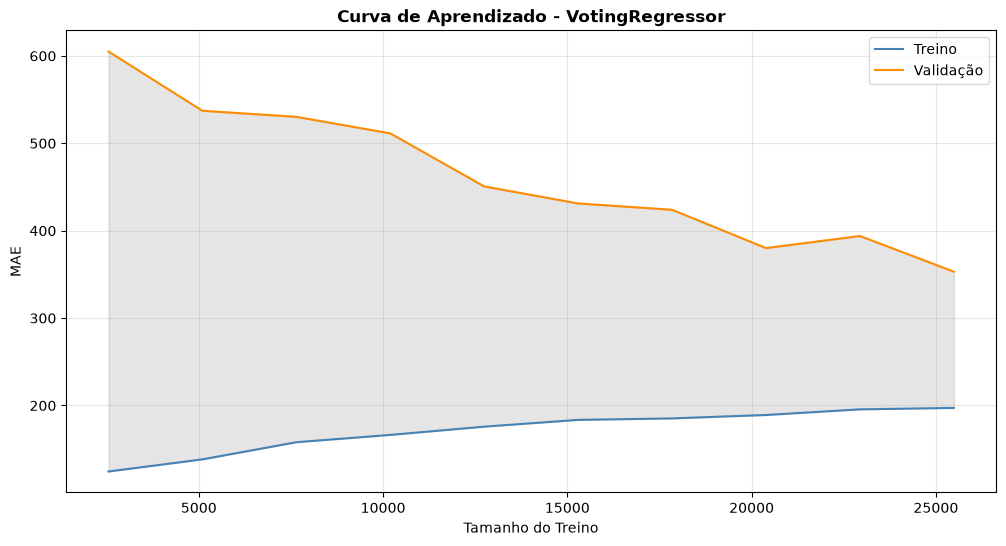

In [37]:
tscv = TimeSeriesSplit(n_splits=5, test_size=4320)

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=modelo_final_voting,
    X= X_modelagem,
    y= y_modelagem,
    cv=tscv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
val_mean = -validation_scores.mean(axis=1)

plt.figure(figsize=(12, 6))

plt.plot(train_sizes, train_mean, label='Treino', color='steelblue')
plt.plot(train_sizes, val_mean, label='Validação', color='darkorange')
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.2, color="gray")

plt.title("Curva de Aprendizado - VotingRegressor",fontweight="bold")
plt.xlabel("Tamanho do Treino")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [38]:
gap_final = val_mean[-1] - train_mean[-1]

print(f"MAE - Treino: {train_mean[-1]:.4f}")
print(f"MAE - Validação: {val_mean[-1]:.4f}")
print(f"GAP Final -> {gap_final:.4f}")

MAE - Treino: 197.2417
MAE - Validação: 353.0749
GAP Final -> 155.8333


### Observação

A curva de aprendizado apresenta um comportamento consistente: conforme o volume de dados de treinamento aumenta, o erro de validação diminui progressivamente, enquanto o erro de treino cresce de forma moderada e tende à estabilização.

No maior conjunto avaliado, o MAE de treino foi de aproximadamente **197,24** e o MAE de validação de **353,07**, resultando em um gap de cerca de **155,83**.

Embora exista diferença entre os desempenhos de treino e validação, as curvas não apresentam sinais de divergência crescente. Pelo contrário, o erro de validação continua diminuindo à medida que mais dados são utilizados.

Dessa forma, o modelo não apresenta indícios de **overfitting acentuado**, mantendo uma capacidade de generalização satisfatória. A tendência observada também sugere que a inclusão de mais dados pode contribuir para reduzir ainda mais o erro de validação.

# 14. Avaliação Final — Conjunto de Teste

Após a seleção do Voting Regressor, o modelo é treinado utilizando todo o conjunto destinado à modelagem e avaliado sobre o período final, mantido isolado das etapas anteriores.

Essa etapa representa a avaliação definitiva do modelo em dados não utilizados durante o processo de validação e seleção.

In [39]:
modelo_final = VotingRegressor(
        estimators=[
            ("xgboost", modelo_xgb_tunado),
            ("lightgbm", modelo_gbm_tunado)
        ],
        n_jobs=-1
    )

modelo_final.fit(X_modelagem, y_modelagem)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgboost', ...), ('lightgbm', ...)]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[XGBRegressor(...ree=None, ...), LGBMRegressor... verbosity=-1)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U18](14,)","['temperatura','umidade','velocidade_vento',...,'dia_da_semana','hora_sin', 'hora_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,14
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'xgboost': X...verbosity=-1)}
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None


In [40]:
previsoes_finais = modelo_final.predict(X_teste_final)

previsoes_finais = pd.Series(
    previsoes_finais,
    index=y_teste_final.index,
    name="previsao"
)

## 14.1 Desempenho no Teste Final

O desempenho é avaliado por meio das métricas MAE, RMSE e MAPE, utilizando o mês reservado como conjunto de teste final.

Os resultados obtidos foram:

- **MAE:** 208,72
- **RMSE:** 306,24
- **MAPE:** aproximadamente 0,76%

Os valores indicam elevada proximidade entre as previsões do modelo e os consumos observados no período de teste.

In [41]:
metricas_finais = calcula_metricas(y_teste_final, previsoes_finais)
metricas_finais_df = pd.DataFrame(metricas_finais, index=["VotingRegression_Final"])
metricas_finais_df

,MAE,RMSE,MAPE
VotingRegression_Final,208.718953,306.236869,0.007619


## 14.2 Consumo Real vs. Previsto

A série prevista é comparada visualmente com os valores reais do conjunto de teste, permitindo avaliar a capacidade do modelo de acompanhar as oscilações da demanda ao longo do período.

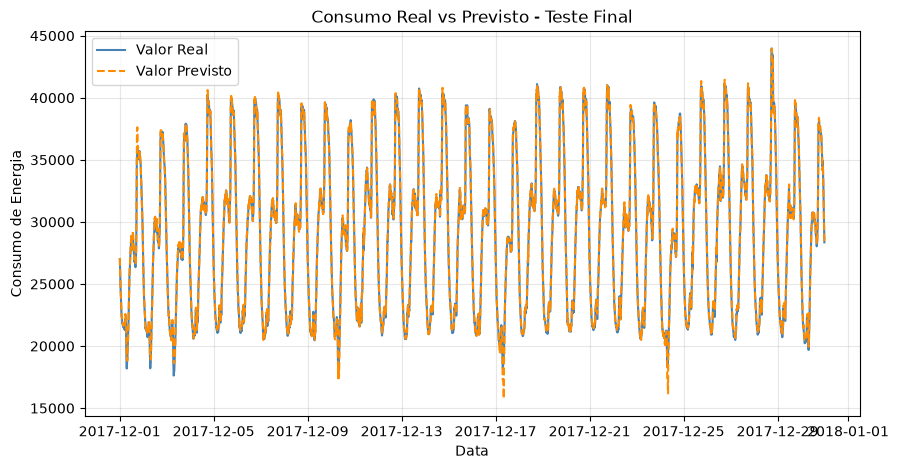

In [42]:
plt.figure(figsize=(10,5))

plt.plot(y_teste_final.index, y_teste_final, label="Valor Real", color='steelblue')
plt.plot(previsoes_finais.index, previsoes_finais, label="Valor Previsto", color='darkorange', linestyle='--')

plt.title("Consumo Real vs Previsto - Teste Final")
plt.xlabel("Data")
plt.ylabel("Consumo de Energia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observação

As previsões acompanham de forma bastante próxima o comportamento real da série, reproduzindo os ciclos de aumento e redução do consumo ao longo do mês.

A proximidade entre as duas curvas é consistente com o baixo erro observado nas métricas e indica boa capacidade de generalização no período avaliado.

## 14.3 Análise dos Resíduos

Os resíduos são analisados para verificar a diferença entre os valores reais e previstos e identificar possíveis padrões sistemáticos de erro.

Um comportamento desejável apresenta resíduos concentrados em torno de zero, sem tendência evidente e com distribuição aproximadamente simétrica.

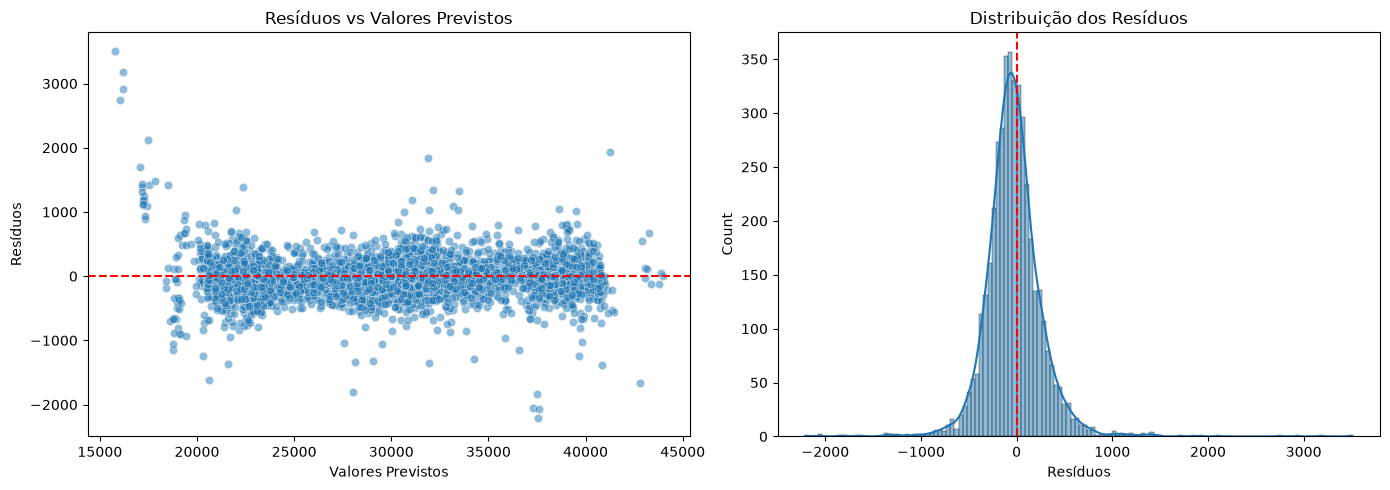

In [43]:
residuos = y_teste_final - previsoes_finais

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=previsoes_finais, y=residuos, alpha=0.5, ax=axes[0])
axes[0].axhline(0.0, color='red', linestyle='--')
axes[0].set_title("Resíduos vs Valores Previstos")
axes[0].set_xlabel("Valores Previstos")
axes[0].set_ylabel("Resíduos")

sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].axvline(0.0, color='red', linestyle='--')
axes[1].set_title("Distribuição dos Resíduos")
axes[1].set_xlabel("Resíduos")

plt.tight_layout()
plt.show()

### Observação

Os resíduos permanecem majoritariamente concentrados em torno de zero, indicando ausência de viés sistemático relevante nas previsões.

A distribuição apresenta forte concentração próxima ao centro, embora existam alguns valores extremos associados a situações específicas em que o modelo apresentou erros maiores.

No gráfico de resíduos versus valores previstos não é observado um padrão estrutural dominante, sugerindo que os erros permanecem relativamente bem distribuídos ao longo dos diferentes níveis de consumo.

# 15. Interpretabilidade do Modelo — SHAP

Após a seleção do Voting Regressor como modelo final, é utilizada a biblioteca SHAP para interpretar como as variáveis contribuem para as previsões.

Como o modelo final é um ensemble, é utilizado o `PermutationExplainer`, permitindo analisar o comportamento do modelo de forma agnóstica à sua estrutura interna.

Para reduzir o custo computacional, a explicação é realizada sobre uma amostra representativa do conjunto de teste.

In [44]:
X_background = shap.sample(
    X_modelagem,
    100,
    random_state=42
)

X_shap = shap.sample(
    X_teste_final,
    300,
    random_state=42
)

In [45]:
explainer = shap.Explainer(
    modelo_final.predict,
    X_background,
    algorithm="permutation"
)

shap_values = explainer(X_shap)

PermutationExplainer explainer: 301it [09:06,  1.82s/it]                         


## 15.1 Importância Global das Variáveis

A importância global é calculada a partir da magnitude média dos valores SHAP, indicando quais variáveis exercem maior influência sobre as previsões do modelo.

Quanto maior o valor médio absoluto de SHAP, maior a contribuição da variável para as decisões do modelo.

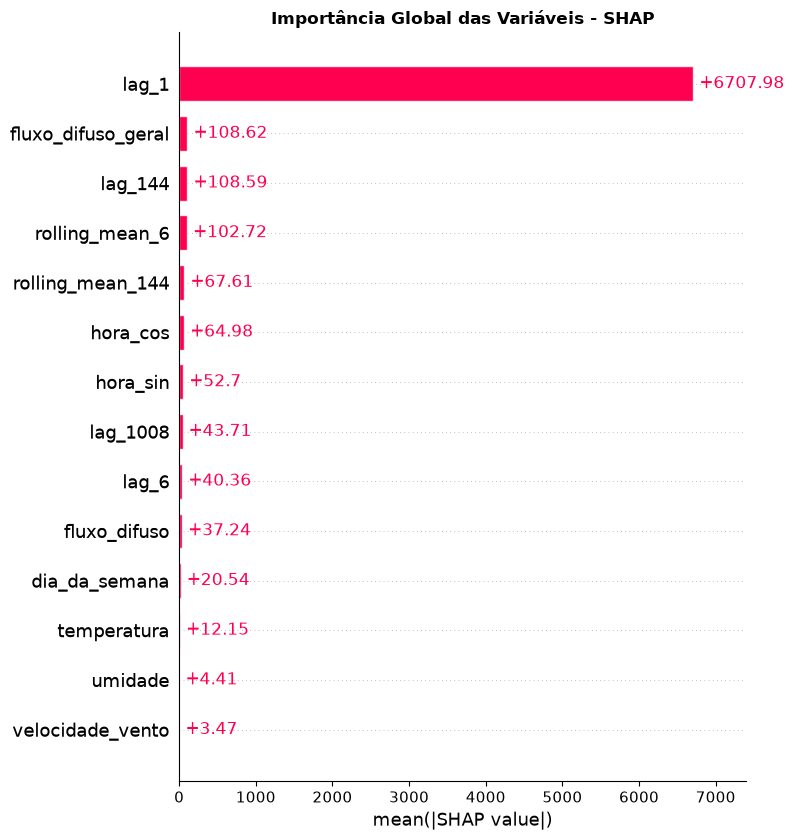

In [46]:
shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title("Importância Global das Variáveis - SHAP", fontweight="bold")
plt.tight_layout()
plt.show()

### Observação

O `lag_1` apresenta importância muito superior às demais variáveis, evidenciando que o consumo observado 10 minutos antes é a principal referência utilizada pelo modelo.

Outras variáveis, como `lag_144`, `fluxo_difuso_geral` e `rolling_mean_6`, também contribuem para as previsões, porém com impacto significativamente menor.

## 15.2 Impacto das Variáveis nas Previsões

O gráfico Beeswarm complementa a análise de importância ao mostrar não apenas a magnitude, mas também a direção do impacto de cada variável.

Valores SHAP positivos aumentam a previsão de consumo, enquanto valores negativos reduzem a estimativa produzida pelo modelo.

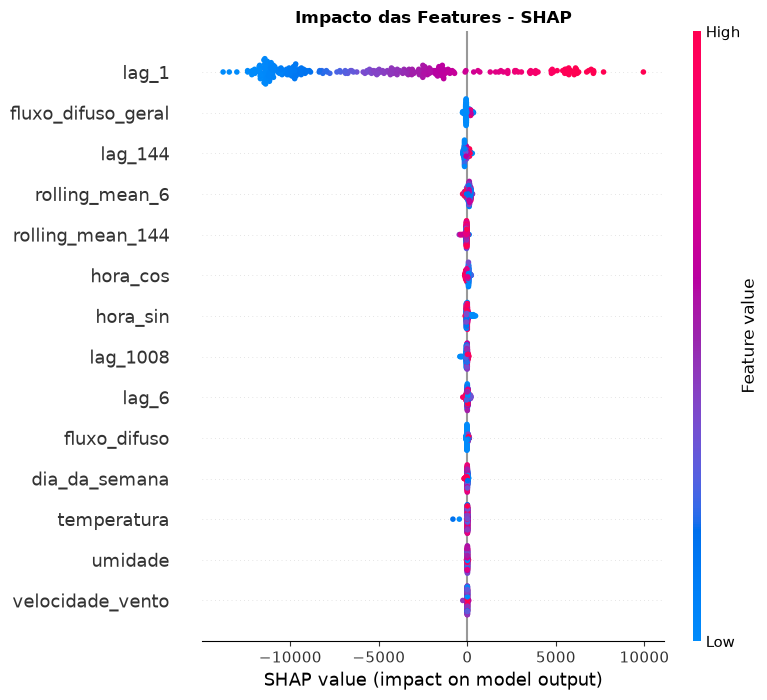

In [47]:
shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "Impacto das Features - SHAP",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Observação

O `lag_1` apresenta novamente o maior impacto sobre a saída do modelo.

Valores elevados dessa variável tendem a contribuir positivamente para a previsão, enquanto valores mais baixos reduzem o consumo estimado.

As demais features apresentam impactos mais concentrados próximos de zero, atuando principalmente como informações complementares.

## 15.3 Dependência do Lag 1

Como `lag_1` apresentou a maior importância global, sua influência sobre as previsões é analisada individualmente.

O gráfico relaciona o valor do consumo observado 10 minutos antes com sua contribuição SHAP para a previsão atual.

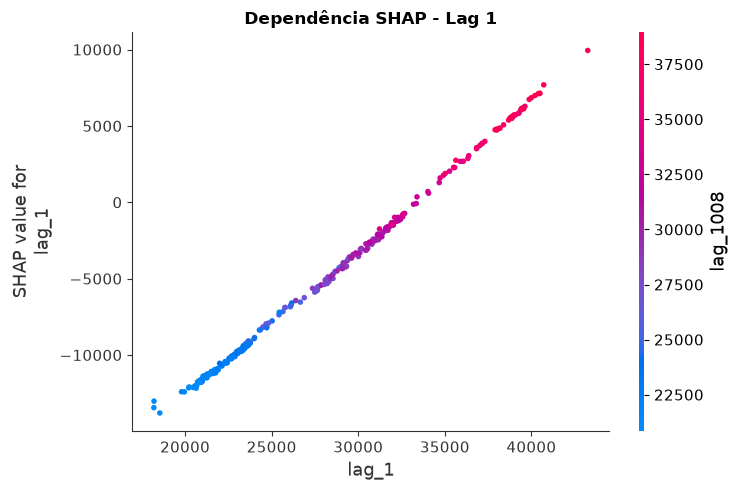

In [48]:
feature_dependence = "lag_1"

shap.dependence_plot(
    feature_dependence,
    shap_values.values,
    X_shap,
    show=False
)
plt.title("Dependência SHAP - Lag 1", fontweight="bold")
plt.tight_layout()
plt.show()

### Observação

Existe uma relação positiva e bastante consistente entre `lag_1` e sua contribuição para a previsão.

À medida que o consumo anterior aumenta, o valor SHAP também cresce, mostrando que o modelo utiliza fortemente a persistência de curto prazo da série.

Esse comportamento é coerente com a elevada autocorrelação identificada anteriormente na análise exploratória.

## 15.4 Explicação Individual de uma Previsão

O gráfico Waterfall permite decompor uma previsão específica, mostrando como cada variável contribuiu para deslocar o valor esperado do modelo até a previsão final.

Contribuições positivas aumentam o valor previsto, enquanto contribuições negativas reduzem a estimativa.

Data -> 2017-12-02 01:20:00
Valor Real -> 23069.20
Valor Previsto -> 23210.44


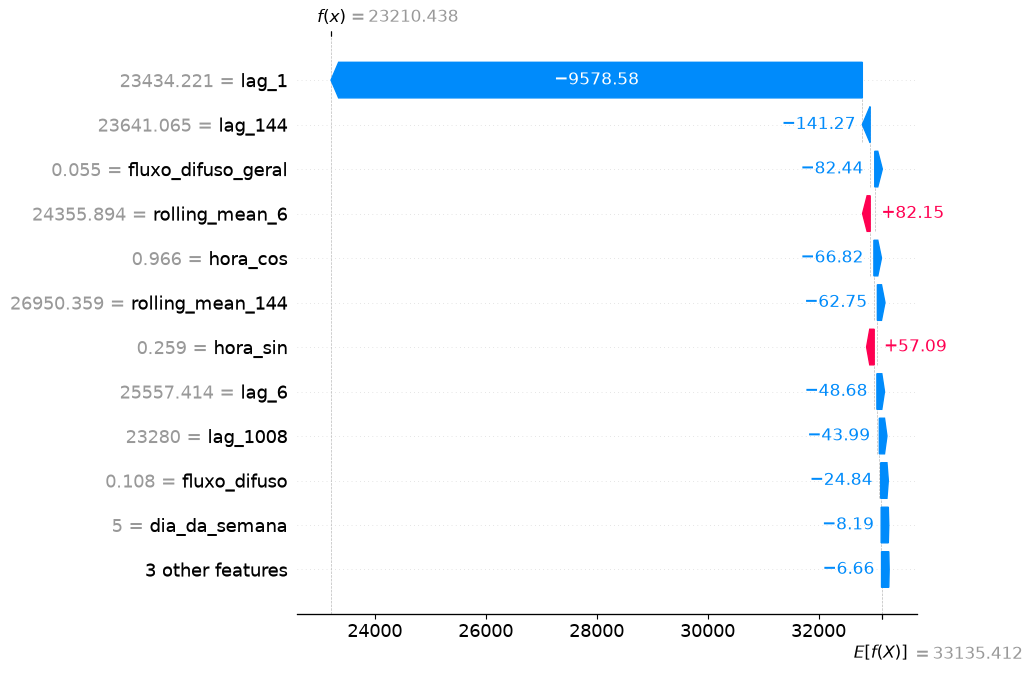

In [49]:
# 3. Explicação individual
indice_consumo = 3

consumo_df = X_shap.iloc[[indice_consumo]]
data_consumo = consumo_df.index[0]

valor_real = y_teste_final.loc[data_consumo]
valor_previsto = modelo_final.predict(consumo_df)[0]

print(f"Data -> {data_consumo}")
print(f"Valor Real -> {valor_real:.2f}")
print(f"Valor Previsto -> {valor_previsto:.2f}")

shap.plots.waterfall(
    shap_values[indice_consumo],
    max_display=12
)

### Observação

Na observação analisada, o valor real foi de aproximadamente **23.069**, enquanto o modelo previu cerca de **23.210**, indicando pequena diferença entre previsão e valor observado.

O valor esperado global do modelo era de aproximadamente **33.135**, porém o `lag_1` exerceu uma forte contribuição negativa, reduzindo a previsão em aproximadamente **9.575 unidades**.

As demais variáveis realizaram ajustes menores, demonstrando novamente que o consumo imediatamente anterior é o principal fator responsável pela previsão neste instante específico.

# 16. Aplicação do Modelo e Forecast Mensal

Após a seleção e avaliação do XGBoost como modelo final, o modelo é treinado novamente utilizando todo o histórico disponível.

Nesta etapa, é realizada uma simulação do consumo energético para os próximos 30 dias.

Como o XGBoost utiliza lags e médias móveis, as previsões são geradas de forma recursiva: cada valor previsto passa a compor o histórico utilizado na previsão seguinte.

O horizonte de 30 dias corresponde a 4.320 intervalos de 10 minutos.

## 16.1 Treinamento com Todo o Histórico

Após a avaliação final, o XGBoost é treinado novamente utilizando todo o conjunto de dados disponível para modelagem.

O objetivo passa a ser utilizar todo o histórico conhecido para gerar previsões futuras.

In [50]:
X_total = dados_ml.drop(columns="consumo_zona_1")
y_total = dados_ml["consumo_zona_1"]

modelo_producao = modelo_final

modelo_producao.fit(X_total, y_total)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgboost', ...), ('lightgbm', ...)]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[XGBRegressor(...ree=None, ...), LGBMRegressor... verbosity=-1)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U18](14,)","['temperatura','umidade','velocidade_vento',...,'dia_da_semana','hora_sin', 'hora_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,14
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'xgboost': X...verbosity=-1)}
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None


## 16.2 Definição do Horizonte de Previsão

Como cada observação representa um intervalo de 10 minutos, um período de 30 dias corresponde a 4.320 previsões.

As datas futuras são criadas mantendo a mesma frequência temporal da série original.

In [51]:
horizonte = 4320

datas_futuras = pd.date_range(
    start=dados_ml.index.max() + pd.Timedelta(minutes=10),
    periods=horizonte,
    freq="10min"
)

print(f"Início -> {datas_futuras.min()}")
print(f"Fim -> {datas_futuras.max()}")
print(f"Previsões -> {len(datas_futuras)}")

Início -> 2017-12-31 00:00:00
Fim -> 2018-01-29 23:50:00
Previsões -> 4320


## 16.3 Cenário das Variáveis Meteorológicas

O XGBoost utiliza variáveis meteorológicas como temperatura, umidade, velocidade do vento e fluxos difusos.

Como essas informações não estão disponíveis para o período futuro, a aplicação utiliza os últimos 30 dias observados como cenário meteorológico para a simulação.

Em uma aplicação real, essas variáveis deveriam ser fornecidas por uma API ou serviço de previsão meteorológica.

In [52]:
variaveis_clima = [
    "temperatura",
    "umidade",
    "velocidade_vento",
    "fluxo_difuso_geral",
    "fluxo_difuso"
]

clima_futuro = (
    dados_ml[variaveis_clima]
    .iloc[-4320:]
    .copy()
)

clima_futuro.index = datas_futuras

## 16.4 Forecast dos Próximos 30 Dias

A previsão é realizada de forma recursiva.

Após cada previsão, o valor estimado é incorporado ao histórico e utilizado na construção dos lags e médias móveis necessários para prever o próximo intervalo.

In [53]:
historico = dados_ml["consumo_zona_1"].copy()

previsoes = []

In [54]:
for data_hora in datas_futuras:

    clima = clima_futuro.loc[data_hora]

    X_futuro = pd.DataFrame({
        "temperatura": [clima["temperatura"]],
        "umidade": [clima["umidade"]],
        "velocidade_vento": [clima["velocidade_vento"]],
        "fluxo_difuso_geral": [clima["fluxo_difuso_geral"]],
        "fluxo_difuso": [clima["fluxo_difuso"]],

        "lag_1": [historico.iloc[-1]],
        "lag_6": [historico.iloc[-6]],
        "lag_144": [historico.iloc[-144]],
        "lag_1008": [historico.iloc[-1008]],

        "rolling_mean_6": [historico.iloc[-6:].mean()],
        "rolling_mean_144": [historico.iloc[-144:].mean()],

        "dia_da_semana": [data_hora.dayofweek],

        "hora_sin": [
            np.sin(2 * np.pi * data_hora.hour / 24)
        ],

        "hora_cos": [
            np.cos(2 * np.pi * data_hora.hour / 24)
        ]
    }, index=[data_hora])

    # Mantém exatamente as mesmas features e ordem do treinamento
    X_futuro = X_futuro[X_total.columns]

    previsao = modelo_producao.predict(X_futuro)[0]

    previsoes.append(previsao)

    # A previsão passa a fazer parte do histórico
    historico.loc[data_hora] = previsao

In [55]:
forecast_df = pd.DataFrame(
    {
        "consumo_previsto": previsoes
    },
    index=datas_futuras
)

forecast_df.head()

,consumo_previsto
2017-12-31 00:00:00,27648.920991
2017-12-31 00:10:00,27061.984663
2017-12-31 00:20:00,26505.257849
2017-12-31 00:30:00,25929.513079
2017-12-31 00:40:00,25427.156337


## 16.5 Evolução do Consumo Previsto

Para facilitar a interpretação do horizonte mensal, as previsões de 10 minutos são agregadas em médias horárias.

O gráfico apresenta o comportamento observado no último mês e a projeção para os próximos 30 dias.

In [56]:
historico_horario = (
    dados_ml["consumo_zona_1"]
    .iloc[-4320:]
    .resample("D")
    .mean()
)

forecast_horario = (
    forecast_df["consumo_previsto"]
    .resample("D")
    .mean()
)

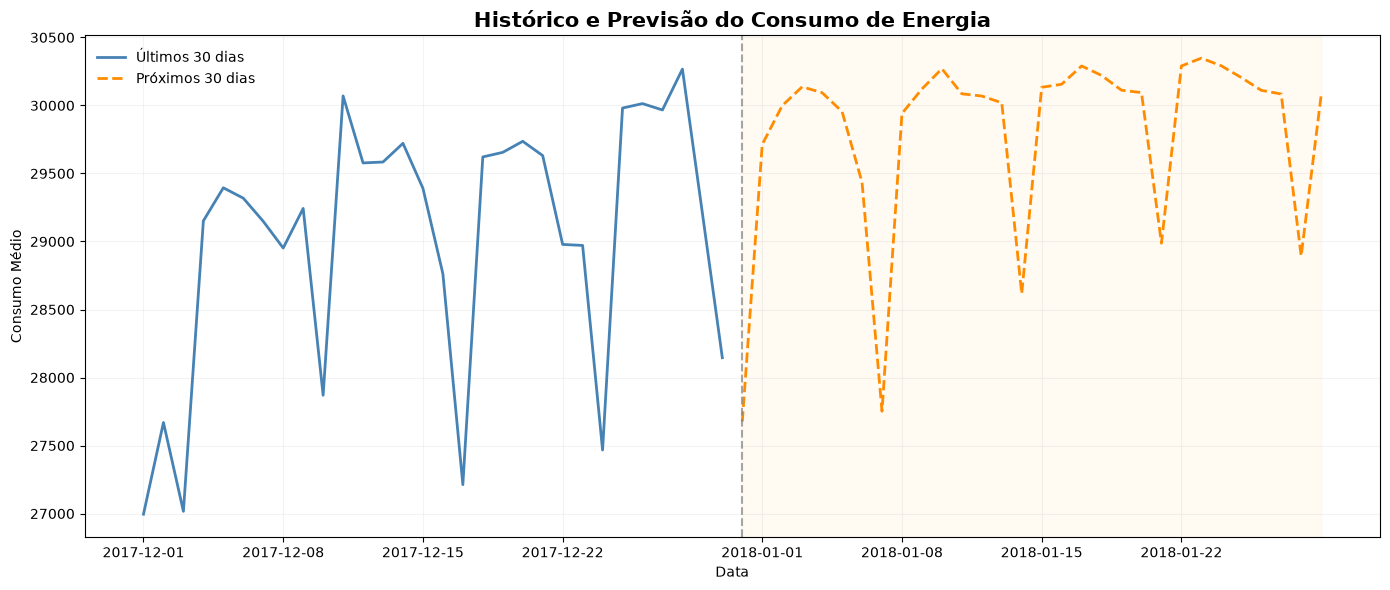

In [57]:
plt.figure(figsize=(14, 6))

plt.plot(historico_horario.index, historico_horario, color="steelblue", linewidth=2, label="Últimos 30 dias")

plt.plot(forecast_horario.index, forecast_horario, color="darkorange", linewidth=2, linestyle="--", label="Próximos 30 dias")

plt.axvline(dados_ml.index.max(), color="gray", linestyle="--", alpha=0.7)

plt.axvspan(forecast_horario.index.min(), forecast_horario.index.max(), color="orange", alpha=0.05)

plt.title("Histórico e Previsão do Consumo de Energia", fontsize=15, fontweight="bold")

plt.xlabel("Data")
plt.ylabel("Consumo Médio")

plt.legend(frameon=False)
plt.grid(alpha=0.15)
plt.tight_layout()

plt.show()

## 16.6 Períodos de Maior e Menor Demanda

A partir das previsões são identificados os períodos de maior e menor consumo esperado durante o próximo mês.

In [58]:
data_max = forecast_df["consumo_previsto"].idxmax()
valor_max = forecast_df["consumo_previsto"].max()

data_min = forecast_df["consumo_previsto"].idxmin()
valor_min = forecast_df["consumo_previsto"].min()

print(
    f"Maior consumo previsto -> "
    f"{valor_max:.2f} em {data_max}"
)

print(
    f"Menor consumo previsto -> "
    f"{valor_min:.2f} em {data_min}"
)

Maior consumo previsto -> 41271.45 em 2018-01-22 18:30:00
Menor consumo previsto -> 19297.56 em 2018-01-07 07:40:00


## 16.7 Resumo da Previsão

Os principais indicadores do forecast são consolidados para fornecer uma visão resumida da demanda energética esperada para o próximo mês.

In [59]:
media_prevista = forecast_df["consumo_previsto"].mean()

resumo_forecast = pd.DataFrame({
    "Indicador": [
        "Consumo médio previsto",
        "Maior consumo previsto",
        "Menor consumo previsto"
    ],
    "Valor": [
        media_prevista,
        valor_max,
        valor_min
    ]
})

resumo_forecast.round(2)

,Indicador,Valor
0,Consumo médio previsto,29805.78
1,Maior consumo previsto,41271.45
2,Menor consumo previsto,19297.56


## 16.8 Comparação com o Último Mês Observado

Para contextualizar a previsão, o consumo médio esperado para os próximos 30 dias é comparado com o consumo médio observado nos últimos 30 dias.

Essa análise permite identificar se o modelo projeta crescimento, redução ou estabilidade da demanda.

In [60]:
ultimo_mes = dados_ml["consumo_zona_1"].iloc[-4320:]

media_ultimo_mes = ultimo_mes.mean()
media_proximo_mes = forecast_df["consumo_previsto"].mean()

variacao_absoluta = (
    media_proximo_mes - media_ultimo_mes
)

variacao_percentual = (
    variacao_absoluta / media_ultimo_mes
) * 100

In [61]:
print(f"Média último mês -> {media_ultimo_mes:.2f}")
print(f"Média próximo mês -> {media_proximo_mes:.2f}")
print(f"Variação absoluta -> {variacao_absoluta:.2f}")
print(f"Variação percentual -> {variacao_percentual:.2f}%")

Média último mês -> 29024.17
Média próximo mês -> 29805.78
Variação absoluta -> 781.62
Variação percentual -> 2.69%


In [62]:
comparacao_mensal = pd.DataFrame({
    "Período": [
        "Últimos 30 Dias",
        "Próximos 30 Dias"
    ],
    "Consumo Médio": [
        media_ultimo_mes,
        media_proximo_mes
    ]
})

comparacao_mensal.round(2)

,Período,Consumo Médio
0,Últimos 30 Dias,29024.17
1,Próximos 30 Dias,29805.78


# 17. Pipeline do Modelo

Após a seleção do Voting Regressor como modelo final, é construído um pipeline para reunir o pré-processamento e o modelo em um único fluxo de inferência.

O pipeline aplica imputação pela mediana para tratar possíveis valores ausentes e, em seguida, executa o ensemble composto por XGBoost e LightGBM.

Após o treinamento com os dados disponíveis, uma previsão é realizada para validar o funcionamento do fluxo completo.

Por fim, o pipeline é salvo em formato `.pkl` com `Joblib`, permitindo sua reutilização em aplicações, APIs e rotinas futuras de previsão.

In [63]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [64]:
X_total = dados_ml.drop(columns="consumo_zona_1")
y_total = dados_ml["consumo_zona_1"]

In [65]:
features_numericas = X_total.select_dtypes(include=np.number).columns.tolist()

print(f"Features Numéricas -> {features_numericas}")

Features Numéricas -> ['temperatura', 'umidade', 'velocidade_vento', 'fluxo_difuso_geral', 'fluxo_difuso', 'lag_1', 'lag_6', 'lag_144', 'lag_1008', 'rolling_mean_6', 'rolling_mean_144', 'dia_da_semana', 'hora_sin', 'hora_cos']


In [66]:
pipeline_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("modelo_final", modelo_final)
])

In [67]:
pipeline_final.fit(X_total, y_total)

amostra = X_total.iloc[[-1]]
previsao = pipeline_final.predict(amostra)[0]

print(f"Valor previsto -> {previsao:.2f}")

joblib.dump(
    pipeline_final,
    "../models/pipeline_final.pkl"
)

Valor previsto -> 28325.32


FileNotFoundError: [Errno 2] No such file or directory: '../models/pipeline_final.pkl'

# 18. Conclusão da Modelagem

A etapa de modelagem permitiu comparar diferentes estratégias para previsão do consumo energético da Zona 1, combinando modelos estatísticos, algoritmos de Machine Learning e técnicas de Ensemble Learning.

Os principais resultados foram:

- **Validação temporal:** todos os modelos foram avaliados com `TimeSeriesSplit`, preservando a ordem cronológica da série e evitando embaralhamento entre passado e futuro.
- **Feature Engineering:** foram incorporados lags, médias móveis, variáveis temporais e informações meteorológicas para representar a dinâmica do consumo.
- **Modelos avaliados:** Holt-Winters, Random Forest, XGBoost, LightGBM, Voting Regressor e Stacking Regressor.
- **Otimização:** XGBoost e LightGBM foram ajustados com `RandomizedSearchCV`, e o XGBoost também foi explorado com Optuna.
- **Melhor abordagem:** o **Voting Regressor**, combinando XGBoost e LightGBM, apresentou o melhor desempenho médio durante a validação temporal.
- **Validação final:** no conjunto de teste reservado, o modelo alcançou aproximadamente **MAE = 208,72**, **RMSE = 306,24** e **MAPE = 0,76%**.
- **Generalização:** a Learning Curve não apresentou sinais de overfitting acentuado, e o erro de validação continuou diminuindo com o aumento dos dados de treinamento.
- **Resíduos:** os erros permaneceram majoritariamente concentrados em torno de zero, sem evidência de viés sistemático relevante.
- **Interpretabilidade:** a análise SHAP mostrou que `lag_1` é a variável mais importante para o modelo, confirmando a forte persistência de curto prazo da série.
- **Pipeline final:** o modelo foi incorporado a um pipeline com tratamento de valores ausentes e serializado com `Joblib`, preparando a solução para reutilização em aplicações.

### Resultado Final

O projeto mostrou que a combinação entre **Feature Engineering temporal, validação adequada e modelos de boosting em ensemble** foi capaz de representar com alta precisão o comportamento do consumo energético.

O desempenho elevado está diretamente relacionado à forte dependência temporal da série, especialmente ao consumo observado nos instantes imediatamente anteriores.

Por esse motivo, os resultados devem ser interpretados principalmente como um cenário de **previsão de curtíssimo prazo com atualização contínua das informações históricas**, e não como uma previsão de longo horizonte realizada de uma única vez.

Com a modelagem concluída, o projeto avança para a etapa de aplicação, utilizando o pipeline final para gerar previsões e disponibilizar os resultados em uma interface Streamlit.